# 04 - Modeling and Evaluation

**Mục tiêu:** huấn luyện, tune threshold và đánh giá mô hình phát hiện giao dịch gian lận.

Mô hình được huấn luyện bằng src/train.py trên dữ liệu processed. Threshold tuning được thực hiện trên validation split theo F1-score, sau đó đánh giá trên toàn bộ test set. Notebook này đọc lại metrics, classification report và biểu đồ để đưa vào báo cáo.


## 1. Setup


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent

TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

print("Project root:", PROJECT_ROOT)
print("Model dir:", MODEL_DIR)


Project root: D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata
Model dir: D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata\models


## 2. Model Metrics

Do dữ liệu mất cân bằng mạnh, các metric quan trọng nhất là Precision, Recall, F1-score, ROC-AUC và PR-AUC. Accuracy chỉ dùng để tham khảo. PR-AUC đặc biệt hữu ích vì tập fraud là lớp thiểu số.


In [2]:
metrics = pd.read_csv(TABLE_DIR / "model_metrics.csv")
metrics


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,base_model,threshold_strategy,threshold
0,random_forest_tuned_f1,0.983607,0.180182,0.914685,0.301059,0.989935,0.744064,random_forest,tuned_f1,0.50
1,random_forest_default_0_50,0.983607,0.180182,0.914685,0.301059,0.989935,0.744064,random_forest,default_0_50,0.50
2,logistic_regression_tuned_f1,0.984915,0.157704,0.669930,0.255308,0.905479,0.118880,logistic_regression,tuned_f1,0.71
3,logistic_regression_default_0_50,0.939320,0.045145,0.730536,0.085036,0.905479,0.118880,logistic_regression,default_0_50,0.50


## 3. Classification Reports


In [3]:
pd.read_csv(TABLE_DIR / "classification_reports_all_models.csv")


,model,class,precision,recall,f1-score,support
0,logistic_regression_default_0_50,0,0.998891,0.940129,0.968619,553574.000000
1,logistic_regression_default_0_50,1,0.045145,0.730536,0.085036,2145.000000
2,logistic_regression_default_0_50,accuracy,0.939320,0.939320,0.939320,0.939320
3,logistic_regression_default_0_50,macro avg,0.522018,0.835333,0.526828,555719.000000
4,logistic_regression_default_0_50,weighted avg,0.995209,0.939320,0.965209,555719.000000
5,logistic_regression_tuned_f1,0,0.998705,0.986136,0.992380,553574.000000
6,logistic_regression_tuned_f1,1,0.157704,0.669930,0.255308,2145.000000
7,logistic_regression_tuned_f1,accuracy,0.984915,0.984915,0.984915,0.984915
8,logistic_regression_tuned_f1,macro avg,0.578204,0.828033,0.623844,555719.000000
9,logistic_regression_tuned_f1,weighted avg,0.995459,0.984915,0.989535,555719.000000


## 4. Confusion Matrix


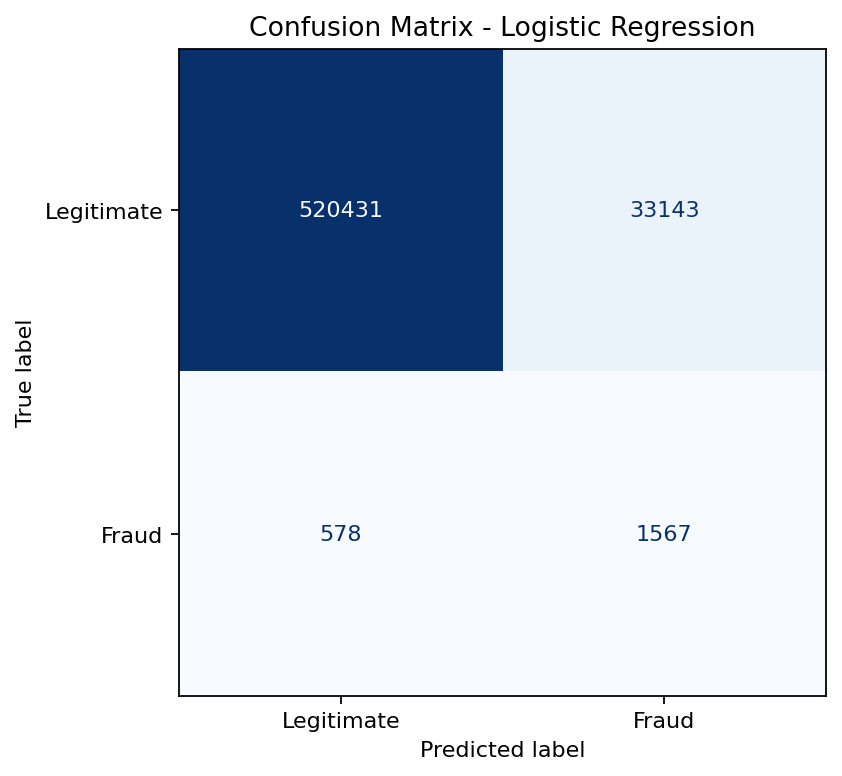

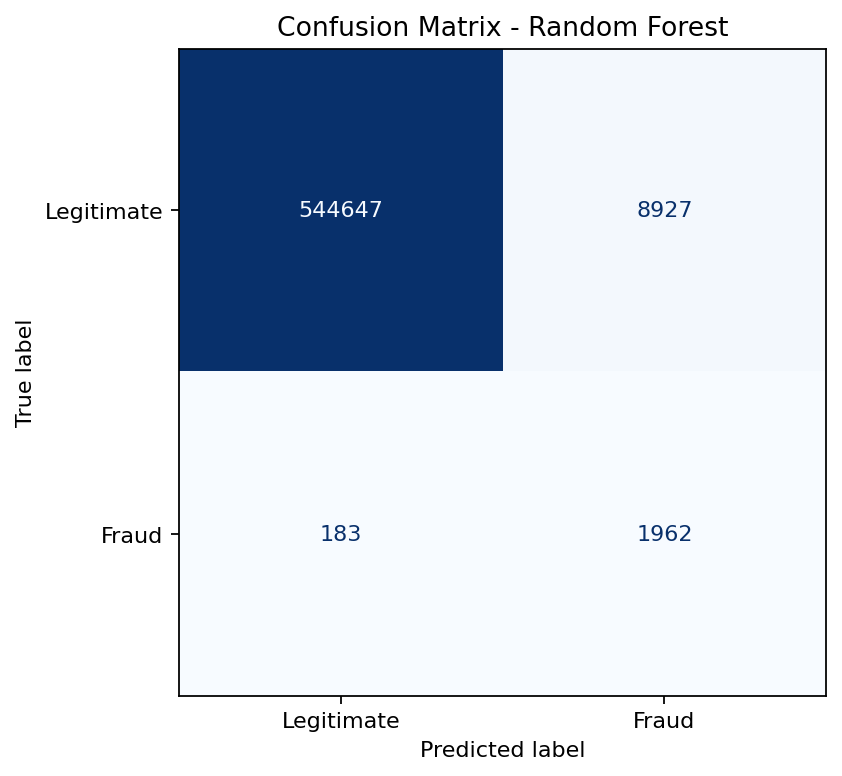

In [4]:
display(Image(filename=str(FIGURE_DIR / "confusion_matrix_logistic_regression.png")))
display(Image(filename=str(FIGURE_DIR / "confusion_matrix_random_forest.png")))


## 5. ROC Curve and Metrics Comparison


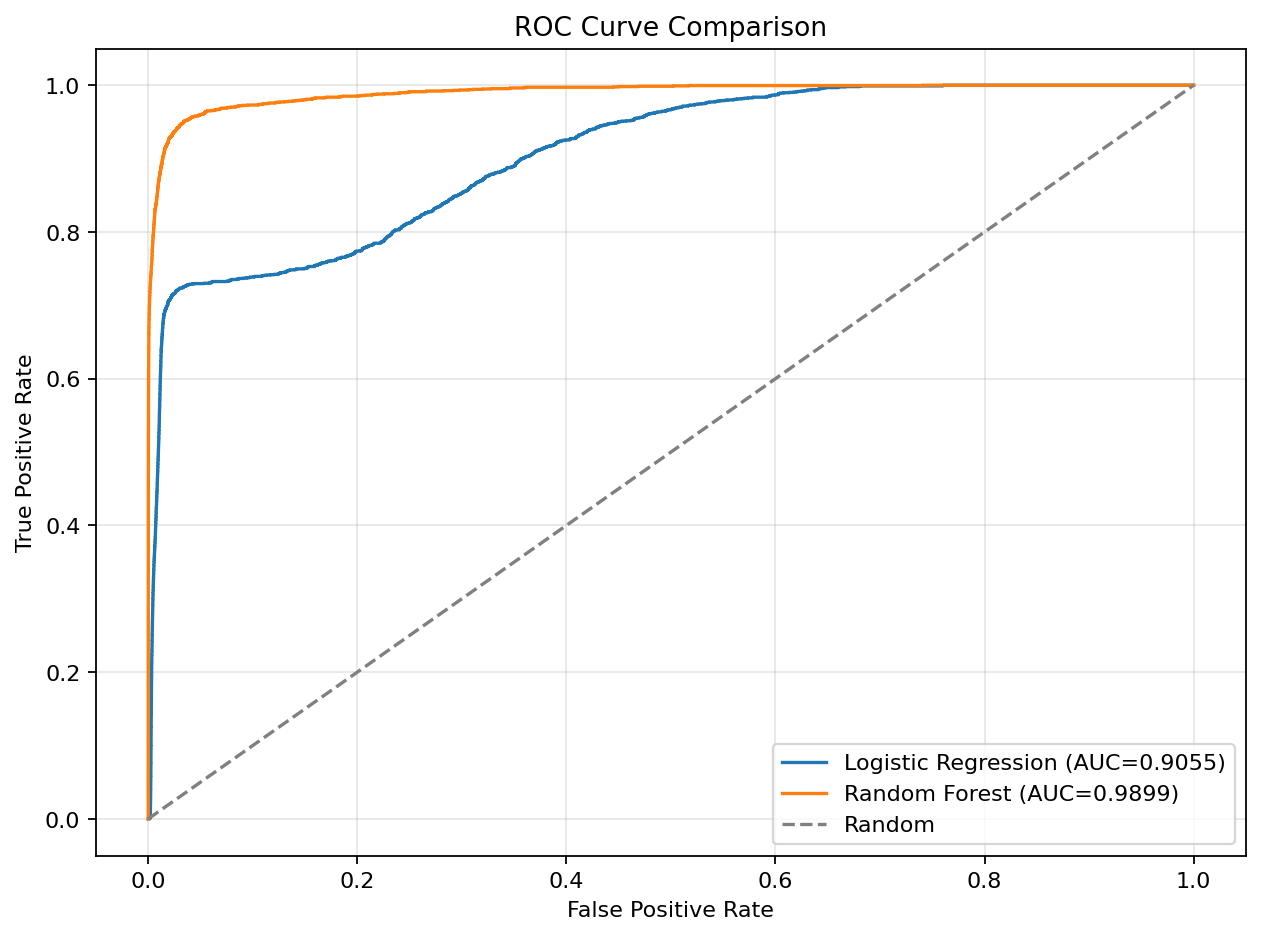

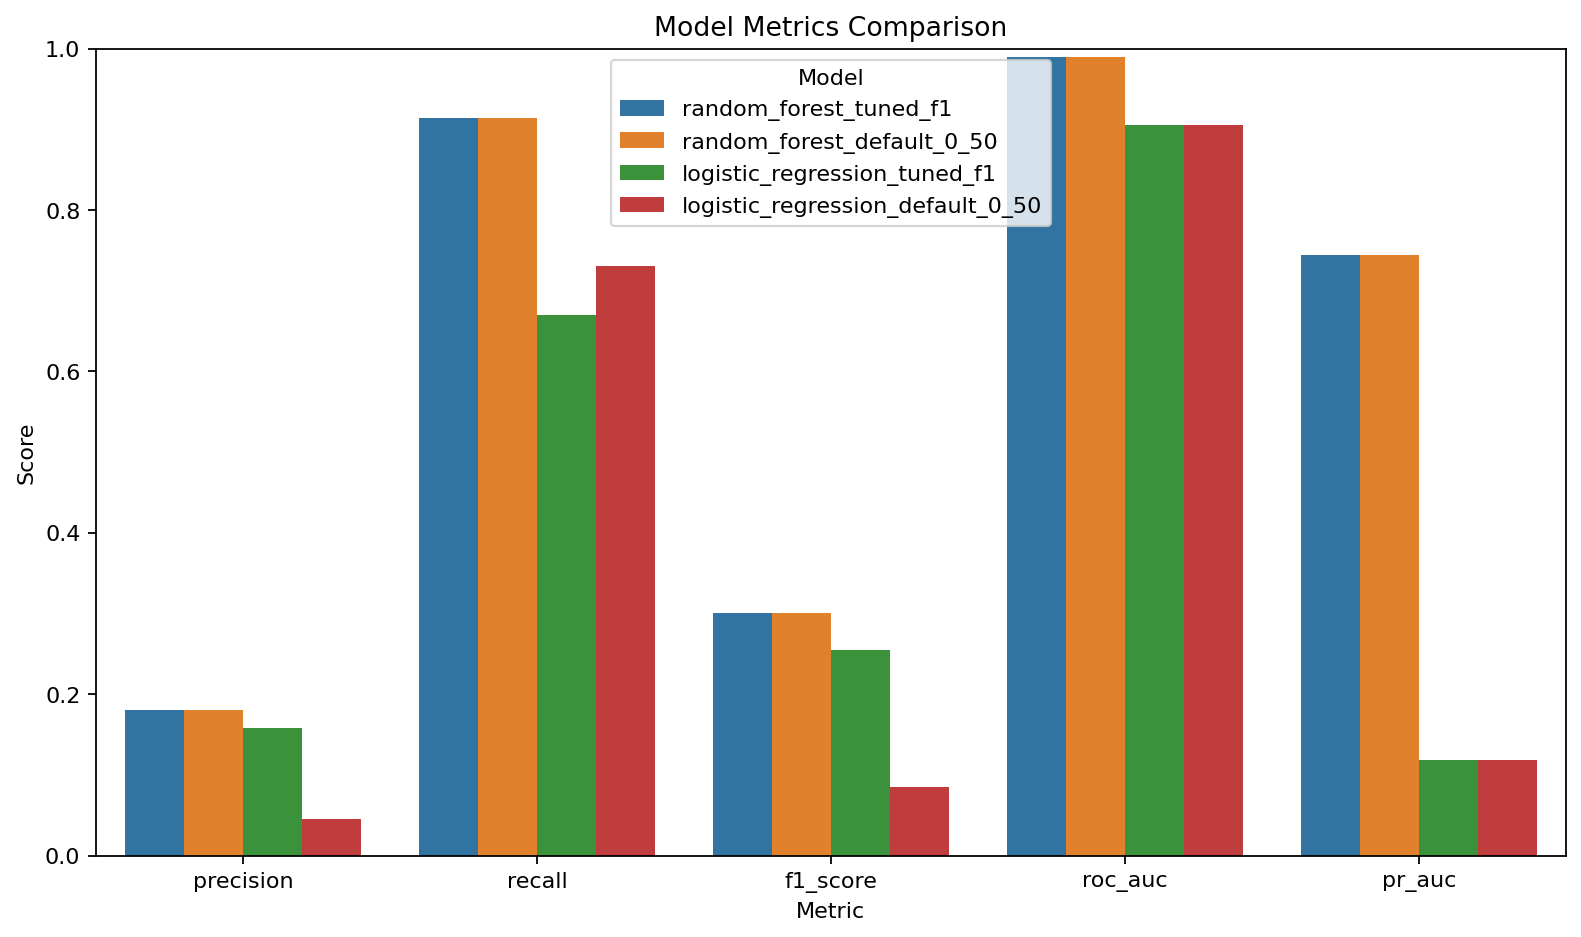

In [5]:
display(Image(filename=str(FIGURE_DIR / "roc_curve_models.png")))
display(Image(filename=str(FIGURE_DIR / "model_metrics_comparison.png")))


## 6. Conclusion

Random Forest cho kết quả tốt nhất trên test set, đặc biệt ở Recall, ROC-AUC và PR-AUC. Threshold tuning cải thiện rõ Logistic Regression: F1-score tăng mạnh khi threshold được chọn theo validation set. Với fraud detection, Recall cao giúp giảm số giao dịch gian lận bị bỏ sót, còn Precision thấp là thách thức tự nhiên do fraud rất hiếm.
